# Evaluator: Visibility Degree — Core Mechanisms

This streamlined evaluator retains only the three focal figures:

1. **Best-solution rank** — the end-state outcome.
2. **Pairwise solution diversity** — the diversity/exploration mechanism.
3. **Adopted-solution fitness** — the quality mechanism.

It also adds a fourth figure that overlays the three series after min–max normalization so their shapes can be compared on the same scale.

For the combined figure, best-solution rank is reverse coded after normalization because a **lower numerical rank is better**. Thus, all three normalized lines are oriented so that higher values are visually more favorable. The combined figure is a shape comparison rather than a mathematical decomposition of best-solution rank.


In [22]:
import warnings
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np

legend_properties = {'weight': 'bold'}

# NUS colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi colors
morandi_blue = "#046586"
morandi_green = "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"
strong_red = "#A61C5D"
strong_blue = "#1B64A4"


def format_axis(ax):
    """Use consistent axis formatting across figures."""
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.grid(alpha=0.5)
    return ax


In [23]:
# =========================
# Configuration
# =========================
agent_num = 200
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
visibility_prob_list = [
    0.0, 0.005, 0.01, 0.02, 0.04, 0.08,
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0
]
visibility_interval = 10

condition_order = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

# Only the two original DVs needed for the focal figures.
base_dvs = [
    "breakthrough_rank",
    "pairwise_diversity",
]

# Candidate folders. The evaluator chooses the first folder containing
# the expected G→G visibility-degree output.
candidate_folders = [
    Path(r"/Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge"),
    Path.cwd(),
]

def folder_has_visibility_degree_results(folder):
    if not folder.exists():
        return False

    pattern = (
        f"gg_visibility_prob_*_interval_{visibility_interval}_"
        f"breakthrough_rank_across_K_size_{agent_num}"
    )
    return any(folder.glob(pattern))

result_folder = next(
    (
        folder
        for folder in candidate_folders
        if folder_has_visibility_degree_results(folder)
    ),
    candidate_folders[0],
)

# To force a specific folder, uncomment and edit this line:
# result_folder = Path(r"/Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge")

print("Result folder:", result_folder)
print("Visibility interval:", visibility_interval)
print("Folder exists:", result_folder.exists())


Result folder: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge
Visibility interval: 10
Folder exists: True


In [24]:
# =========================
# Load focal visibility-degree results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)


def result_file(prefix, visibility_prob, dv):
    return result_folder / (
        f"{prefix}_visibility_prob_{visibility_prob}_"
        f"interval_{visibility_interval}_{dv}_across_K_size_{agent_num}"
    )


def load_core_results(prefixes=condition_order, strict=True):
    """
    Expected shape for each data[prefix][dv]:
        (len(visibility_prob_list), len(K_list))
    """
    data = {}
    missing_files = []
    wrong_length = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in base_dvs:
            rows = []

            for visibility_prob in visibility_prob_list:
                path = result_file(prefix, visibility_prob, dv)

                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)

                if values.ndim != 1 or len(values) != len(K_list):
                    wrong_length.append(
                        (path.name, values.shape, (len(K_list),))
                    )

                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if wrong_length:
        print("\nFiles with unexpected K dimension:")
        for name, observed, expected in wrong_length[:30]:
            print(
                f"  - {name}: observed={observed}; "
                f"expected={expected}"
            )

        if strict:
            raise ValueError(
                "Some core result files have unexpected shapes."
            )

    if missing_files:
        print("\nMissing core result files:")
        for path in missing_files[:30]:
            print("  -", path.name)

        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        if strict:
            raise FileNotFoundError(
                "Some expected core visibility-degree files are missing."
            )

    return data


def load_adoption_quality_results(prefixes=condition_order, strict=True):
    """
    Expected shape:
        adoption_data[prefix]["adopted_solution_fitness"]
        -> (visibility degree, K)
    """
    adoption_data = {}
    missing_files = []
    wrong_shapes = []

    for prefix in prefixes:
        adoption_data[prefix] = {}
        rows = []

        for visibility_prob in visibility_prob_list:
            path = result_file(
                prefix,
                visibility_prob,
                "adopted_solution_fitness",
            )

            if not path.exists():
                missing_files.append(path)
                continue

            values = np.asarray(load_pickle(path), dtype=float)

            if values.ndim != 1 or len(values) != len(K_list):
                wrong_shapes.append(
                    (path.name, values.shape, (len(K_list),))
                )

            rows.append(values)

        if rows:
            adoption_data[prefix][
                "adopted_solution_fitness"
            ] = np.vstack(rows)

    if wrong_shapes:
        print("\nAdoption-quality files with unexpected shapes:")
        for name, observed, expected in wrong_shapes[:30]:
            print(
                f"  - {name}: observed={observed}; "
                f"expected={expected}"
            )

        if strict:
            raise ValueError(
                "Some adoption-quality files have unexpected shapes."
            )

    if missing_files:
        print("\nMissing adopted-solution-fitness files:")
        for path in missing_files[:30]:
            print("  -", path.name)

        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        if strict:
            raise FileNotFoundError(
                "Some expected adopted-solution-fitness files are missing."
            )

    return adoption_data


data = load_core_results(strict=True)
adoption_data = load_adoption_quality_results(strict=True)

print("\nLoaded shapes:")
for prefix in condition_order:
    print(
        prefix,
        "rank:", data[prefix]["breakthrough_rank"].shape,
        "pairwise diversity:",
        data[prefix]["pairwise_diversity"].shape,
        "adopted fitness:",
        adoption_data[prefix]["adopted_solution_fitness"].shape,
    )



Loaded shapes:
gg rank: (16, 8) pairwise diversity: (16, 8) adopted fitness: (16, 8)
gs rank: (16, 8) pairwise diversity: (16, 8) adopted fitness: (16, 8)
sg rank: (16, 8) pairwise diversity: (16, 8) adopted fitness: (16, 8)
ss rank: (16, 8) pairwise diversity: (16, 8) adopted fitness: (16, 8)


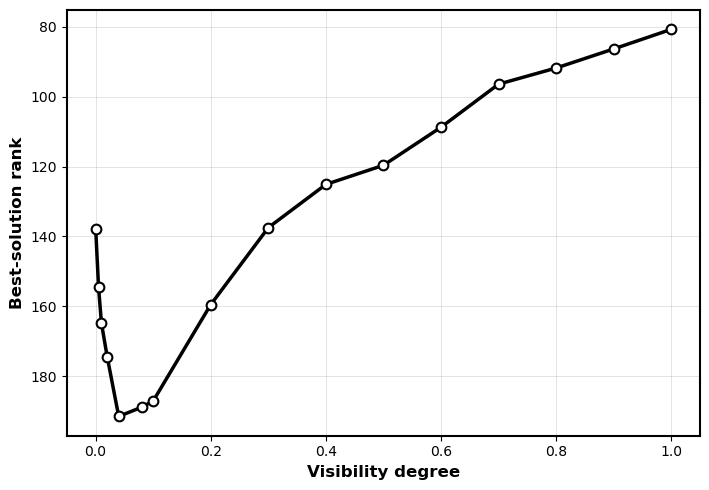

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/Rank_across_visibility.png


In [33]:
# =========================
# Figure 1: Averaged best-solution rank across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# First average each condition across K; then average across
# the four G-S visibility conditions.
y = np.mean(
    [
        data[prefix]["breakthrough_rank"].mean(axis=1)
        for prefix in condition_order
    ],
    axis=0,
)

ax.plot(
    x, y,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="k",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

ax.invert_yaxis()
ax.set_xlabel(
    "Visibility degree",
    fontweight="bold",
    fontsize=12,
)
ax.set_ylabel(
    "Best-solution rank",
    fontweight="bold",
    fontsize=12,
)

plt.tight_layout()

output_png = result_folder / "Rank_across_visibility.png"
plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

print("Saved:", output_png)


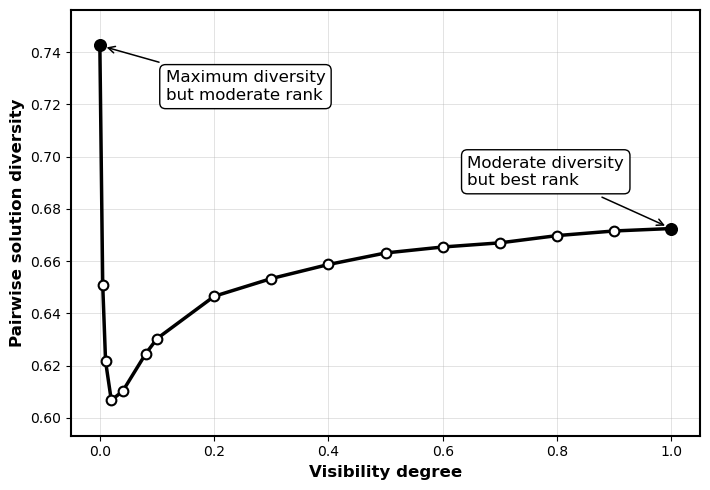

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/Pairwise_diversity_across_visibility.png


In [29]:
# =========================
# Figure 2: Averaged pairwise solution diversity across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = np.asarray(visibility_prob_list)

# First average each condition across K; then average across
# the four G-S visibility conditions.
y = np.mean(
    [
        data[prefix]["pairwise_diversity"].mean(axis=1)
        for prefix in condition_order
    ],
    axis=0,
)

# Identify zero-visibility and full-visibility benchmark points
zero_idx = np.where(np.isclose(x, 0.0))[0][0]
full_idx = np.where(np.isclose(x, 1.0))[0][0]

zero_x, zero_y = x[zero_idx], y[zero_idx]
full_x, full_y = x[full_idx], y[full_idx]

# -------------------------
# Main curve
# -------------------------
ax.plot(
    x, y,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="k",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
    zorder=2,
)

# Give the two endpoint observations some breathing room
ax.set_xlim(-0.05, 1.05)
ax.margins(y=0.10)

# Highlight the two focal observations
ax.scatter(
    zero_x,
    zero_y,
    s=70,
    color="black",
    zorder=3,
)

ax.scatter(
    full_x,
    full_y,
    s=70,
    color="black",
    zorder=3,
)

# -------------------------
# Annotation-box style
# -------------------------
textbox_style = dict(
    boxstyle="round,pad=0.35",
    facecolor="white",
    edgecolor="black",
    linewidth=1.0,
)

arrow_style = dict(
    arrowstyle="->",
    linewidth=1.1,
    color="black",
    shrinkA=5,
    shrinkB=5,
)

# -------------------------
# Zero visibility annotation
# -------------------------
ax.annotate(
    "Maximum diversity\nbut moderate rank",
    xy=(zero_x, zero_y),
    xycoords="data",
    xytext=(0.15, 0.82),
    textcoords="axes fraction",
    ha="left",
    va="center",
    fontsize=12,
    # fontweight="bold",
    bbox=textbox_style,
    arrowprops=arrow_style,
    annotation_clip=True,
    zorder=4,
)

# -------------------------
# Full visibility annotation
# -------------------------
ax.annotate(
    "Moderate diversity\nbut best rank",
    xy=(full_x, full_y),
    xycoords="data",
    xytext=(0.63, 0.62),
    textcoords="axes fraction",
    ha="left",
    va="center",
    fontsize=12,
    # fontweight="bold",
    bbox=textbox_style,
    arrowprops=arrow_style,
    annotation_clip=True,
    zorder=4,
)

# -------------------------
# Axes
# -------------------------
ax.set_xlabel(
    "Visibility degree",
    fontweight="bold",
    fontsize=12,
)

ax.set_ylabel(
    "Pairwise solution diversity",
    fontweight="bold",
    fontsize=12,
)

plt.tight_layout()

output_png = (
    result_folder
    / "Pairwise_diversity_across_visibility.png"
)

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

print("Saved:", output_png)

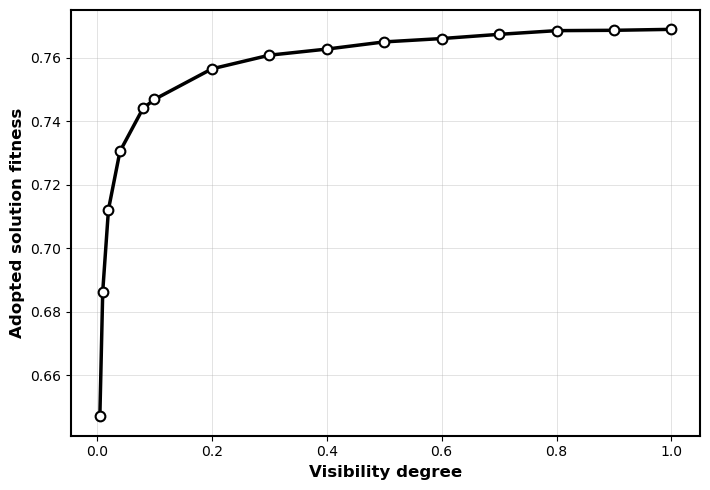

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/Adopted_solution_quality_across_visibility.png


In [32]:
# =========================
# Figure 3: Averaged adopted-solution fitness across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# Shape: (condition, visibility degree, K)
adoption_stack = np.stack(
    [
        adoption_data[prefix]["adopted_solution_fitness"]
        for prefix in condition_order
    ],
    axis=0,
)

# Average across both condition and K.
# Undefined no-adoption observations remain NaN rather than zero.
with warnings.catch_warnings():
    warnings.simplefilter(
        "ignore",
        category=RuntimeWarning,
    )
    y = np.nanmean(
        adoption_stack,
        axis=(0, 2),
    )

ax.plot(
    x, y,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="k",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

ax.set_xlabel(
    "Visibility degree",
    fontweight="bold",
    fontsize=12,
)
ax.set_ylabel(
    "Adopted solution fitness",
    fontweight="bold",
    fontsize=12,
)

plt.tight_layout()

output_png = (
    result_folder
    / "Adopted_solution_quality_across_visibility.png"
)
plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

print("Saved:", output_png)


## Combined mechanism figure

The next figure places the outcome and the two mechanisms on the same scale.

- **Best-rank performance (outcome):** best-solution rank is min–max normalized and reverse coded, so higher values mean better rank.
- **Pairwise diversity (exploration):** min–max normalized directly.
- **Adopted-solution fitness (quality):** min–max normalized directly.

This makes the three *shapes* directly comparable while preserving the original raw-value figures above. It should be interpreted as a visual synthesis of the two mechanisms, not as evidence that best-solution rank is an arithmetic average of the two mechanism variables.


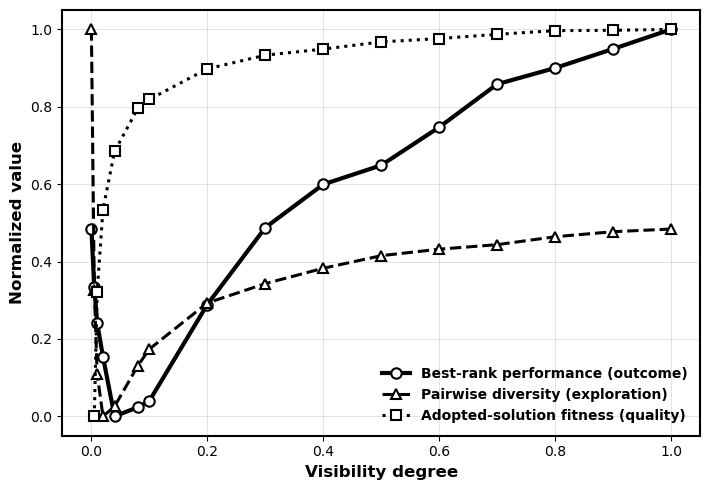

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig9_joint_mechanism_overlay_normalized.png


In [28]:
# =========================
# Figure 4: Joint mechanism view
# Best-rank performance + pairwise diversity + adopted-solution fitness
# =========================

def minmax_normalize(values, reverse=False):
    """
    Normalize one series to [0, 1], ignoring NaN values.

    reverse=True is used for rank because lower numerical rank is better.
    """
    values = np.asarray(values, dtype=float)

    if np.all(np.isnan(values)):
        return values.copy()

    minimum = np.nanmin(values)
    maximum = np.nanmax(values)

    if np.isclose(maximum, minimum):
        normalized = np.zeros_like(values, dtype=float)
    else:
        normalized = (
            (values - minimum)
            / (maximum - minimum)
        )

    if reverse:
        normalized = 1.0 - normalized

    return normalized


x = np.asarray(visibility_prob_list, dtype=float)

# -------------------------
# Reconstruct the same three averaged series used above
# -------------------------
rank_raw = np.mean(
    [
        data[prefix]["breakthrough_rank"].mean(axis=1)
        for prefix in condition_order
    ],
    axis=0,
)

pairwise_diversity_raw = np.mean(
    [
        data[prefix]["pairwise_diversity"].mean(axis=1)
        for prefix in condition_order
    ],
    axis=0,
)

adoption_stack = np.stack(
    [
        adoption_data[prefix]["adopted_solution_fitness"]
        for prefix in condition_order
    ],
    axis=0,
)

with warnings.catch_warnings():
    warnings.simplefilter(
        "ignore",
        category=RuntimeWarning,
    )
    adopted_fitness_raw = np.nanmean(
        adoption_stack,
        axis=(0, 2),
    )

# -------------------------
# Put all three series on a common 0–1 scale
# -------------------------
rank_performance = minmax_normalize(
    rank_raw,
    reverse=True,
)
pairwise_diversity = minmax_normalize(
    pairwise_diversity_raw,
)
adopted_fitness = minmax_normalize(
    adopted_fitness_raw,
)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

# Outcome: visually strongest line
ax.plot(
    x,
    rank_performance,
    color="black",
    linestyle="-",
    marker="o",
    linewidth=3.0,
    markersize=7.5,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
    label="Best-rank performance (outcome)",
)

# Mechanism 1: exploration / diversity
ax.plot(
    x,
    pairwise_diversity,
    color="black",
    linestyle="--",
    marker="^",
    linewidth=2.2,
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
    label="Pairwise diversity (exploration)",
)

# Mechanism 2: adopted-solution quality
ax.plot(
    x,
    adopted_fitness,
    color="black",
    linestyle=":",
    marker="s",
    linewidth=2.2,
    markersize=6.5,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
    label="Adopted-solution fitness (quality)",
)

ax.set_xlabel(
    "Visibility degree",
    fontweight="bold",
    fontsize=12,
)
ax.set_ylabel(
    "Normalized value",
    fontweight="bold",
    fontsize=12,
)

ax.set_ylim(-0.05, 1.05)

legend = ax.legend(
    frameon=False,
    prop=legend_properties,
    loc="best",
)

plt.tight_layout()

output_png = (
    result_folder
    / "fig9_joint_mechanism_overlay_normalized.png"
)
plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

print("Saved:", output_png)
